<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.2-fine-tuning-png-vs-tensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fine-Tuning con ResNet-18 y EfficientNet-B0

### Introducción: PNG vs. Tensor

Esta es la instancia previa a la elección del mejor modelo para el **Reconocimiento de Emociones en el Habla (SER)**. En este notebook, se entrenarán modelos utilizando dos enfoques de entrada distintos:

1.  **Imágenes (PNG):** Espectrogramas de Mel generados y guardados previamente como archivos de imagen.
2.  **Tensores 3D:** Datos procesados directamente con PyTorch a partir de los **Coeficientes Cepstrales (MFCCs)** y sus **Deltas de primer y segundo orden**. Esto resulta en un tensor de entrada con la estructura `[3, Frecuencia, Tiempo]`.

Analizaremos las métricas de rendimiento, los costos computacionales y, por sobre todo, el alcance de los modelos cuyos datos de entrada fueron imágenes comprimidas en comparación con aquellos entrenados con tensores, los cuales conservan de manera más íntegra la información y la dimensión temporal en sus entradas.

In [20]:
# Imports
#----------------------------------------------------------------
import os
import gc
import glob
import torch
import random
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
#----------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
# Optimizaciones de hardware y fijación de semillas para reproducibilidad
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device en uso: {device}")

Device en uso: cuda


In [4]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local
os.makedirs('/content/ravdess_and_crema_images', exist_ok=True)
#os.makedirs('/content/data_split_tensors', exist_ok=True)
# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp /content/drive/MyDrive/mel_spec_and_mfcc_images.zip /content/mel_spec_mfcc_images.zip
!cp -r /content/drive/MyDrive/data_split_tensors/ /content

!unzip -q /content/mel_spec_mfcc_images.zip -d /content/ravdess_and_crema_images

In [23]:
# Configuraciones y rutas
BASE_DIR_IMG = '/content/ravdess_and_crema_images'
BASE_DIR_TENSOR = '/content/data_split_tensors'
MODELS_SAVE_DIR = '/content/saved_models'
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64 # Ajustable si hay problemas de memoria con DenseNet (Spoiler: Dejar en 64)

# Se recomienda usar la GPU que ofrece Google Colab para acelerar el entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
# Print root_dir content:
img_content = (os.listdir(BASE_DIR_IMG))
tensor_content = (os.listdir(BASE_DIR_TENSOR))

print(f"Contenido de {BASE_DIR_IMG}: {img_content}")
print(f"Contenido de {BASE_DIR_TENSOR}: {tensor_content}")

Contenido de /content/ravdess_and_crema_images: ['mfcc', 'mel_spec']
Contenido de /content/data_split_tensors: ['train_tensors.pt', 'test_tensors.pt', 'val_tensors.pt']


### Dataloaders desde datos con split (Train, Validation, Test)

In [25]:
def get_images_dataloaders(feature_type):


  """
  Construye DataLoaders aislando Train/Val/Test.
  Aplica normalización de ImageNet estrictamente necesaria para el Transfer Learning.
  Nota: ImageFolder convierte automáticamente RGBA a RGB (fondo negro) por defecto.
  """
  feature_dir_img = os.path.join(BASE_DIR_IMG, feature_type)

  transform_pipeline = transforms.Compose([
      #transforms.Resize(224,224), # Cambiar si la imagen de origen no es 224x224
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

  datasets_dict = {}
  for split in ['train', 'val', 'test']:
      split_path = os.path.join(feature_dir_img, split)
      datasets_dict[split] = datasets.ImageFolder(root=split_path, transform=transform_pipeline)


  # Optimizaciones: num_workers=2 y pin_memory=True aceleran la transferencia a la GPU
  train_loader = DataLoader(datasets_dict['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
  val_loader = DataLoader(datasets_dict['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
  test_loader = DataLoader(datasets_dict['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

  class_names = datasets_dict['train'].classes
  print(f"[{feature_type.upper()}] Clases detectadas: {class_names}")
  print(f"Muestras -> Train: {len(datasets_dict['train'])} | Val: {len(datasets_dict['val'])} | Test: {len(datasets_dict['test'])}")

  return train_loader, val_loader, test_loader, class_names

In [36]:
get_images_dataloaders("mfcc")

[MFCC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895


(<torch.utils.data.dataloader.DataLoader at 0x7b5eb85ac770>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

In [7]:
# Mapea índices a clases igual que en extracción
IDX_TO_CLASS = {
    0: 'angry',
    1: 'disgust',
    2: 'fearful',
    3: 'happy',
    4: 'neutral',
    5: 'sad',
    6: 'surprised'
}

CLASS_NAMES = list(IDX_TO_CLASS.values())

def get_tensors_dataloaders(BASE_DIR_TENSOR, BATCH_SIZE):
    datasets_dict = {}

    file_map = {
        'train': 'train_tensors.pt',
        'val': 'val_tensors.pt',
        'test': 'test_tensors.pt'
    }

    for split, filename in file_map.items():
        split_path = os.path.join(BASE_DIR_TENSOR, filename)
        if not os.path.exists(split_path):
            raise FileNotFoundError(f"No existe el archivo de split: {split_path}")
        datasets_dict[split] = torch.load(split_path)

    # Si usas GPU, pin_memory ayuda; en CPU no aporta
    pin = torch.cuda.is_available()

    train_loader = DataLoader(
        datasets_dict['train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=pin
    )
    val_loader = DataLoader(
        datasets_dict['val'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=pin
    )
    test_loader = DataLoader(
        datasets_dict['test'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=pin
    )

    class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]

    print(f"Clases detectadas: {class_names}")
    print(
        f"Muestras -> Train: {len(datasets_dict['train'])} | "
        f"Val: {len(datasets_dict['val'])} | "
        f"Test: {len(datasets_dict['test'])}"
    )

    # sanity check de forma del primer tensor
    x0, y0 = datasets_dict['train'][0]
    print(f"Shape ejemplo train[0]: {tuple(x0.shape)} | label={y0}")

    return train_loader, val_loader, test_loader, class_names


In [8]:
get_tensors_dataloaders(BASE_DIR_TENSOR, BATCH_SIZE)

Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7422 | Val: 830 | Test: 918
Shape ejemplo train[0]: (3, 13, 94) | label=3


(<torch.utils.data.dataloader.DataLoader at 0x784d59863b90>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

### Model Factory Para Tensores

ResNet18 y Efficientnet-b0

In [9]:
class TensorModelFactory:
  @staticmethod
  def get_model(model_name: str, num_classes: int, freeze_base: bool=True):
    if model_name == 'resnet18':
      model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
      # Adaptacion para input pequeño [3,13,94]
      model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
      model.maxpool = nn.Identity()
      if freeze_base:
        for param in model.parameters():
          param.requires_grad = False

      in_features = model.fc.in_features
      model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))

    elif model_name == 'efficientnet_b0':
      model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


      if freeze_base:
          for p in model.parameters():
              p.requires_grad = False

      in_f = model.classifier[1].in_features
      model.classifier = nn.Sequential(
          nn.Dropout(0.4),
          nn.Linear(in_f, num_classes)
      )

    else:
        raise ValueError(f"Modelo no soportado para tensor pipeline: {model_name}")

    return model.to(device)

### Entrenamiento de Red Neuronal

Funcion para entrenar con ResNet o Efficientnet-b0, las funciones de entrenamiento de modelos son muy similares, en ellas podremos configurar los parametros de la red, por ejemplo:
* Directorio donde guaramos  los modelos `save_path`,
* Numero de epocas `epochs`,
* Learning rate o taza de aprendizaje `lr`,
* Numero de intentos antes de detener el entrenamiento `patience`,
* Configuracion de los pesos `weight_decay`.


In [13]:
def train_model_tensor(
    model,
    train_loader,
    val_loader,
    save_path,
    epochs=20,
    lr=1e-3,
    patience=5,
    weight_decay=1e-2
):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_val_loss = float("inf")
    trigger = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # --- Val ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_val_y, all_val_p = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)

                val_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

                all_val_y.extend(y.cpu().numpy())
                all_val_p.extend(preds.cpu().numpy())

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1_macro = f1_score(all_val_y, all_val_p, average='macro')

        scheduler.step(val_loss)
        lr_now = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1:02d}/{epochs}] lr={lr_now:.1e} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1m={val_f1_macro:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            trigger = 0
        else:
            trigger += 1
            print(f"Early stop activado: {trigger}/{patience}")
            if trigger >= patience:
                print("Early stopping.")
                break

    return save_path

Ejecución de entrenamiento

In [29]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH = 'efficientnet_b0'
exp_name = f"tensor_{MODEL_ARCH}"

train_loader, val_loader, test_loader, class_names = get_tensors_dataloaders(
    BASE_DIR_TENSOR,
    BATCH_SIZE
)



phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name}_phase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH, num_classes=len(CLASS_NAMES), freeze_base=True)

best_phase1 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=15,
    lr=1e-3,
    patience=4
)

print("Fase 1, mejor:", best_phase1)

Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7422 | Val: 830 | Test: 918
Shape ejemplo train[0]: (3, 13, 94) | label=3
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


[01/15] lr=1.0e-03 | train_loss=1.9132 acc=0.1998 | val_loss=1.7961 acc=0.2554 f1m=0.2410
[02/15] lr=1.0e-03 | train_loss=1.8147 acc=0.2572 | val_loss=1.7742 acc=0.2627 f1m=0.2548
[03/15] lr=1.0e-03 | train_loss=1.7688 acc=0.2786 | val_loss=1.7771 acc=0.2627 f1m=0.2515
Early stop activado: 1/4
[04/15] lr=1.0e-03 | train_loss=1.7655 acc=0.2871 | val_loss=1.7789 acc=0.2494 f1m=0.2472
Early stop activado: 2/4
[05/15] lr=5.0e-04 | train_loss=1.7650 acc=0.2941 | val_loss=1.7941 acc=0.2627 f1m=0.2511
Early stop activado: 3/4
[06/15] lr=5.0e-04 | train_loss=1.7358 acc=0.2999 | val_loss=1.7805 acc=0.2711 f1m=0.2626
Early stop activado: 4/4
Early stopping.
Fase 1, mejor: /content/saved_models/tensor_efficientnet_b0_phase1.pth


In [31]:
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name}_phase2_unfrozen.pth")

model.load_state_dict(torch.load(best_phase1, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_phase2 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=40,
    lr=1e-5,
    patience=4
)

print("Phase 2 best:", best_phase2)

[01/40] lr=1.0e-05 | train_loss=1.7624 acc=0.2824 | val_loss=1.7597 acc=0.2663 f1m=0.2570
[02/40] lr=1.0e-05 | train_loss=1.7456 acc=0.2979 | val_loss=1.7522 acc=0.2711 f1m=0.2599
[03/40] lr=1.0e-05 | train_loss=1.7174 acc=0.3085 | val_loss=1.7349 acc=0.2747 f1m=0.2647
[04/40] lr=1.0e-05 | train_loss=1.7028 acc=0.3120 | val_loss=1.7379 acc=0.2711 f1m=0.2641
Early stop activado: 1/4
[05/40] lr=1.0e-05 | train_loss=1.6824 acc=0.3242 | val_loss=1.7288 acc=0.2855 f1m=0.2716
[06/40] lr=1.0e-05 | train_loss=1.6704 acc=0.3255 | val_loss=1.7124 acc=0.2831 f1m=0.2695
[07/40] lr=1.0e-05 | train_loss=1.6447 acc=0.3432 | val_loss=1.7126 acc=0.2783 f1m=0.2644
Early stop activado: 1/4
[08/40] lr=1.0e-05 | train_loss=1.6265 acc=0.3560 | val_loss=1.7011 acc=0.2988 f1m=0.2801
[09/40] lr=1.0e-05 | train_loss=1.6114 acc=0.3600 | val_loss=1.6957 acc=0.3048 f1m=0.2867
[10/40] lr=1.0e-05 | train_loss=1.5979 acc=0.3666 | val_loss=1.6804 acc=0.2988 f1m=0.2811
[11/40] lr=1.0e-05 | train_loss=1.5768 acc=0.3778 

Evalucion del modelo

Test Accuracy: 0.3562 | Test F1 macro: 0.3403

              precision    recall  f1-score   support

       angry       0.49      0.65      0.56       150
     disgust       0.39      0.27      0.32       150
     fearful       0.29      0.22      0.25       150
       happy       0.30      0.23      0.26       150
     neutral       0.34      0.24      0.28       144
         sad       0.36      0.47      0.41       150
   surprised       0.20      0.75      0.31        24

    accuracy                           0.36       918
   macro avg       0.34      0.40      0.34       918
weighted avg       0.36      0.36      0.34       918



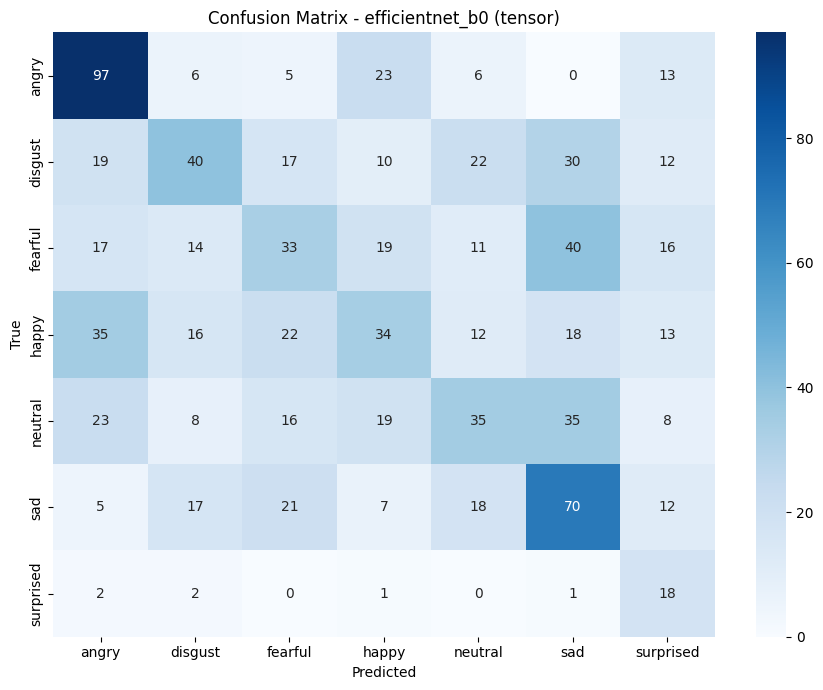

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

def evaluate_tensor_model(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro')
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model(MODEL_ARCH, best_phase2, test_loader, CLASS_NAMES)

### Model Factory para Imagenes

ResNet18 y Efficientnet-b0

In [ ]:
class ImageModelFactory:
    @staticmethod
    def get_model(model_name, num_classes, freeze_base=True):
        """
        Instancia dinámicamente arquitecturas convolucionales y adapta la última capa.
        """
        if model_name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.fc.in_features
            model.fc = nn.Sequential(nn.Dropout(0.7), nn.Linear(num_ftrs, num_classes))

        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

        else:
            raise ValueError(f"Arquitectura {model_name} no soportada.")

        return model.to(device)

In [ ]:
def train_model(model, train_loader, val_loader, model_save_name, epochs=15, lr=1e-3, patience=5):
    """
    Bucle de entrenamiento con Mixed Precision (AMP) y Early Stopping y LR Scheduler.
    """
    criterion = nn.CrossEntropyLoss()
    # Optimiza solo los parámetros que requieren gradiente (útil en Phase 1)
    # Incrementamos weight_decay a 1e-2 para combatir el Overfitting observado
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-2)

    # Configuramos el LR(Dinamico): Reduce el LR a la mitad si el val_loss no mejora en 2 épocas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    trigger_times = 0
    save_path = os.path.join(MODELS_SAVE_DIR, f'{model_save_name}.pth')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Forward pass con AMP para ahorro de memoria
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Phase de Validación
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Actualizamos el Scheduler basado en la métrica de validación
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{epochs}[LR:{current_lr:.1e}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        else:
            trigger_times += 1
            print(f"Early stop trigger activado {trigger_times} / {patience}")
            if trigger_times >= patience:
                print(f"--> Early Stopping disparado en época {epoch+1}.")
                break

    return save_path

In [ ]:

MODES = ['vector', 'png']
TARGET_FEATURE = 'mel_spec' # Opciones: 'mel_spec', 'mfcc'
MODEL_ARCHITECTURE = 'efficientnet_b0' # Opciones: 'resnet18', 'densenet121', 'efficientnet_b0'

# Ensure 'device' refers to the torch.device object, not the sklearn function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Carga de datos (usa los DataLoaders optimizados)
print(f"Cargando datos de: {TARGET_FEATURE.upper()}")
train_loader, val_loader, test_loader, class_names = get_images_dataloaders(TARGET_FEATURE)

# 2. Construcción dinámica mediante el Model Factory
model = ImageModelFactory.get_model(model_name=MODEL_ARCHITECTURE, num_classes=len(class_names), freeze_base=True)

experiment_name = f"{TARGET_FEATURE}_{MODEL_ARCHITECTURE}"

# =====================================================================
# FASE 1: TRANSFER LEARNING (Clasificador Superior)
# =====================================================================
print(f"\n--- INICIANDO FASE 1: Entrenando clasificador de {MODEL_ARCHITECTURE} ---")
best_model_path_phase1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase1",
    epochs=15,
    lr=1e-3, # LR más alto porque solo entrenamos la capa lineal final
    patience=4
)

# =====================================================================
# FASE 2: FINE-TUNING PROFUNDO (Descongelamiento)
# =====================================================================
print(f"\n--- INICIANDO FASE 2: Fine-Tuning profundo ---")
# Restauramos el modelo al punto de menor pérdida en la Fase 1
model.load_state_dict(torch.load(best_model_path_phase1, weights_only=True))

# Descongelamos TODOS los pesos para que los filtros convolucionales se adapten al audio
for param in model.parameters():
    param.requires_grad = True

best_model_path_phase2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase2_unfrozen",
    epochs=40,
    lr=1e-5, # CRÍTICO: LR drásticamente más bajo para no destruir los pesos de ImageNet
    patience=4
)

print(f"\nEntrenamiento Finalizado. Mejor modelo guardado en: {best_model_path_phase2}")

Cargando datos de: MEL_SPEC
[MEL_SPEC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895

--- INICIANDO FASE 1: Entrenando clasificador de efficientnet_b0 ---
Epoch 1/15[LR:1.0e-03] | Train Loss: 1.6736 Acc: 0.3251 | Val Loss: 1.5513 Acc: 0.3883
Epoch 2/15[LR:1.0e-03] | Train Loss: 1.5164 Acc: 0.4075 | Val Loss: 1.5039 Acc: 0.4066
Epoch 3/15[LR:1.0e-03] | Train Loss: 1.4786 Acc: 0.4206 | Val Loss: 1.4881 Acc: 0.4053
Epoch 4/15[LR:1.0e-03] | Train Loss: 1.4555 Acc: 0.4292 | Val Loss: 1.4508 Acc: 0.4248
Epoch 5/15[LR:1.0e-03] | Train Loss: 1.4476 Acc: 0.4317 | Val Loss: 1.4620 Acc: 0.4296
Early stop trigger activado 1 / 4
Epoch 6/15[LR:1.0e-03] | Train Loss: 1.4310 Acc: 0.4416 | Val Loss: 1.4559 Acc: 0.4442
Early stop trigger activado 2 / 4
Epoch 7/15[LR:1.0e-03] | Train Loss: 1.4317 Acc: 0.4402 | Val Loss: 1.4305 Acc: 0.4587
Epoch 8/15[LR:1.0e-03] | Train Loss: 1.4314 Acc: 0.4397 | Val Loss: 1.4439 A

Cargando modelo para evaluación: /content/saved_models/mel_spec_efficientnet_b0_phase2_unfrozen.pth

REPORTE DE CLASIFICACIÓN: EFFICIENTNET_B0
              precision    recall  f1-score   support

       angry       0.56      0.72      0.63       144
     disgust       0.49      0.28      0.36       144
     fearful       0.49      0.57      0.52       144
       happy       0.51      0.55      0.53       144
     neutral       0.49      0.60      0.54       143
         sad       0.56      0.36      0.44       144
   surprised       0.69      0.75      0.72        32

    accuracy                           0.52       895
   macro avg       0.54      0.55      0.53       895
weighted avg       0.52      0.52      0.51       895



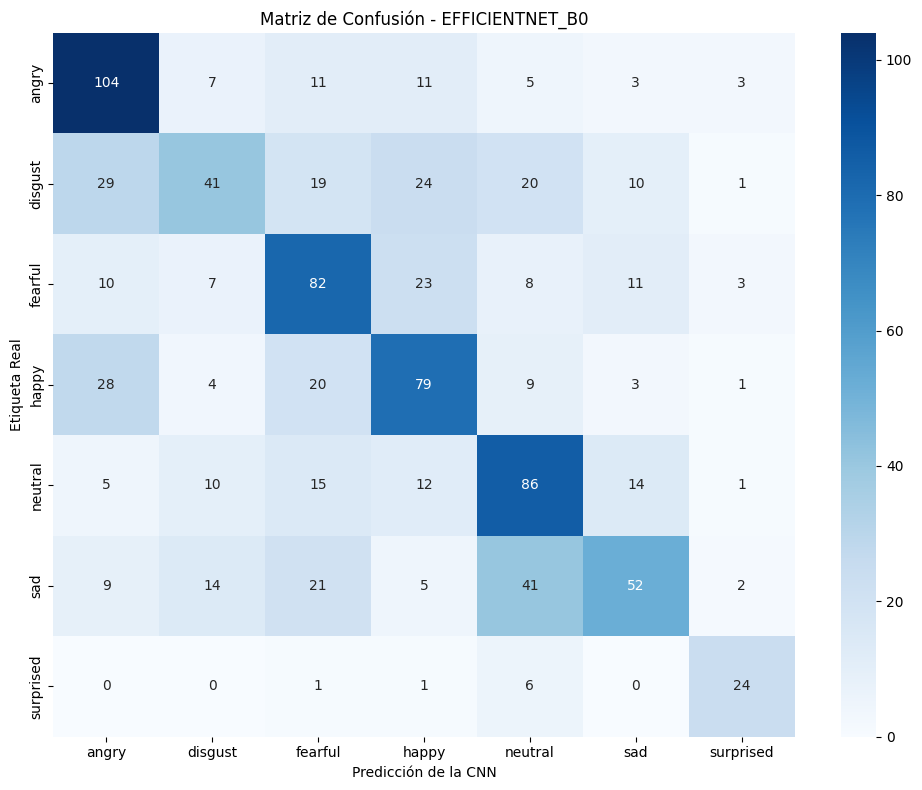

In [ ]:
def evaluate_model(model_path, test_loader, class_names, model_arch):
    """
    Carga los pesos de un modelo entrenado, ejecuta inferencia sobre el Test Set
    y genera métricas de clasificación estandarizadas.
    """
    print(f"Cargando modelo para evaluación: {model_path}")

    # Instanciamos una arquitectura vacía (sin congelar nada) y cargamos los pesos finales
    model = ModelFactory.get_model(model_name=model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    model.eval() # Modo evaluación: congela capas de Dropout y BatchNorm

    all_preds = []
    all_labels = []

    # Desactivar el tracking de gradientes es obligatorio para liberar VRAM en inferencia
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # AMP también se usa en inferencia para mayor velocidad
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

            # Data Handling: Scikit-learn requiere arrays en CPU y en Numpy
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte Estadístico (F1-Score, Precision, Recall)
    print("\n" + "="*60)
    print(f"REPORTE DE CLASIFICACIÓN: {model_arch.upper()}")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Visualización: Matriz de Confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {model_arch.upper()}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción de la CNN')
    plt.tight_layout()
    plt.show()

    # Memory Management: Limpieza de la GPU tras la inferencia
    del model
    torch.cuda.empty_cache()
    gc.collect()

# Ejecutamos la evaluación con el modelo recién entrenado
evaluate_model(
    model_path=best_model_path_phase2,
    test_loader=test_loader,
    class_names=class_names,
    model_arch=MODEL_ARCHITECTURE
)

In [ ]:

# Define la ruta específica que vas a evaluar ahora
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mel_spec_efficientnet_b0_unfrozen'
# Prints
print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")
#Llamado a la funcion evaluadora
evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)



Evaluando modelo: best_model_for_mel_spec_efficientnet_b0_unfrozen



TypeError: evaluate_model() got an unexpected keyword argument 'model'

In [ ]:
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mfcc_efficientnet_b0_unfrozen'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mfcc_densenet121_unfrozen'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta2'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)